##### Import statements:

In [1]:
import os
import pathlib
import inspect
import functools
import pickle
import numpy as np
import pandas as pd
import json
import socket
import multiprocessing as mp
import functools
import itertools
import re
import random
import string
import matplotlib.pyplot as plt

hostname = socket.gethostname()

if 'rc.zi.columbia.edu' in hostname:
    from ws.general import find_df_constants, matches_template, class_def2str
    from ws.simulate_task import load_sim_params, load_task_def, simulate_session
    from ws.miscellaneous_sparseauto import mdl_geometry_pipeline, fmt_ae_metadata, generate_hparams_df, assign_class_labels, ae_dispatch, fit_autoencoder, layer_cols2rows, balance_n_task_labels
    from ws.functions_geometry import geometry_2D, perf_2D
    from ws.plot import plot_iterate_autoencoder_results, plot_ccgps_by_layer, plot_pars_by_layer
    base = os.path.join('/', 'mnt', 'smb', 'locker', 'issa-locker', 'users', 'Dan', 'code', 'ws') 
else:
    from simulation_whiskers.general import find_df_constants, matches_template, class_def2str
    from simulation_whiskers.simulate_task import load_sim_params, load_task_def, simulate_session
    from simulation_whiskers.miscellaneous_sparseauto import mdl_geometry_pipeline, fmt_ae_metadata, generate_hparams_df, assign_class_labels, ae_dispatch, fit_autoencoder, layer_cols2rows, balance_n_task_labels
    from simulation_whiskers.functions_geometry import geometry_2D, perf_2D
    #from simulation_whiskers.plot import plot_iterate_autoencoder_results, plot_autoencoder_geometry
    from simulation_whiskers.plot import plot_iterate_autoencoder_results, plot_ccgps_by_layer, plot_pars_by_layer
    base = os.path.join('C:\\', 'Users', 'danie' 'Documents', 'code_libraries', 'simulation_whiskers')

from analysis_metadata.analysis_metadata import Metadata, increment_dir_name, write_metadata
import time

##### Define inputs, parameters:

In [2]:
task_defs = [
    
    # Task 0:
    [
     functools.partial(matches_template, template={'freq_sh' : 2}), 
     functools.partial(matches_template, template={'freq_sh' : 15})
     ],
    
    # Task 1:
    [
     functools.partial(matches_template, template={'time_mov' : 10}),
     functools.partial(matches_template, template={'time_mov' : 17})
     ]
    ]

# Define default general variables:
n_repeats = 100
n_geo_subsamples = 1
sum_inpt=False
xor=True
zscore_data = False
geo_reg = 1.0

# Define default simulation parameters:
concavity = [0]
n_whisk = 2
prob_poiss = 1.01
noise_w = 0.3
spread = 'auto'
speed = 2.0
ini_phase_m = 0
ini_phase_spr = 100
delay_time = 0
freq_m = 3.0
freq_std = 0.1
std_reset = 0
t_total = 2
dt = 0.1
dx = 0.01
n_trials_pre = 500
amp = 2
freq_sh = [2, 15]
z1 = [4]
max_rad = 50
n_rad = 4
disp = 4.5
theta = [0]
steps_mov = [10, 17]
rad_vec = [6]
init_position = 0

# Manually specify hyperparameter combinations:
hparams_list = None

# Output parameters:
save_output = True
if 'rc.zi.columbia' in hostname:
    base_output_directory = os.path.join(base, 'results', 'input_geo')
else:
    base_output_directory='E:\\simulation_whiskers\\results\\input_geo'
run_base_name='run'

##### Define hyperparameters:

In [3]:
simulation_cols = ['concavity', 'n_whisk', 'prob_poiss', 'noise_w', 'spread',
     'speed', 'ini_phase_m', 'ini_phase_spr', 'delay_time', 'freq_m', 'freq_std',
     'std_reset', 't_total', 'dt', 'dx', 'n_trials_pre', 'amp', 'freq_sh',
     'z1', 'max_rad', 'n_rad', 'disp', 'theta', 'steps_mov', 'rad_vec', 'init_position']

defaults = {'task_defs' : task_defs, 'n_repeats' : n_repeats, 'zscore_data' : zscore_data, 'sum_inpt' : sum_inpt,  'geo_reg' : geo_reg, 
    'concavity' : concavity, 'n_whisk' : n_whisk, 'prob_poiss' : prob_poiss, 'noise_w' : noise_w, 'spread' : spread, 'speed' : speed, 
    'ini_phase_m' : ini_phase_m, 'ini_phase_spr' : ini_phase_spr, 'delay_time' : delay_time, 'freq_m' : freq_m, 'freq_std' : freq_std, 
    'std_reset' : std_reset, 't_total': t_total, 'dt' : dt, 'dx' : dx, 'n_trials_pre' : n_trials_pre, 'amp' : amp, 'freq_sh' : freq_sh, 
    'z1' : z1, 'max_rad' : max_rad, 'n_rad' : n_rad, 'disp' : disp, 'theta' : theta, 'steps_mov' : steps_mov, 'rad_vec' : rad_vec, 
    'init_position' : init_position}

hparams_df = generate_hparams_df(defaults, hparams_list)
"""
sim_params = {
 'concavity' : concavity, 
 'n_whisk' : 'n_whisk', 
 'prob_poiss' : 'prob_poiss', 
 'noise_w' : 'noise_w', 
 'spread' : 'spread',
 'speed' : 'speed', 
 'ini_phase_m' : 'ini_phase_m', 
 'ini_phase_spr' : 'ini_phase_spr', 
 'delay_time' : 'delay_time', 
 'freq_m' : 'freq_m', 
 'freq_std' : 'freq_std',
 'std_reset' : 'std_reset', 
 't_total' : 't_total',  
 'dt' : 'dt', 
 'dx' : 'dx', 
 'n_trials_pre' : 'n_trials_pre', 
 'amp' : 'amp', 
 'freq_sh' : 'freq_sh',
 'z1' : 'z1',  
 'max_rad' : 'max_rad', 
 'n_rad' : 'n_rad', 
 'disp' : 'disp', 
 'theta' : 'theta', 
 'steps_mov' : 'steps_mov', 
 'rad_vec' : , 
 'init_position' :   
}
"""

"\nsim_params = {\n 'concavity' : concavity, \n 'n_whisk' : 'n_whisk', \n 'prob_poiss' : 'prob_poiss', \n 'noise_w' : 'noise_w', \n 'spread' : 'spread',\n 'speed' : 'speed', \n 'ini_phase_m' : 'ini_phase_m', \n 'ini_phase_spr' : 'ini_phase_spr', \n 'delay_time' : 'delay_time', \n 'freq_m' : 'freq_m', \n 'freq_std' : 'freq_std',\n 'std_reset' : 'std_reset', \n 't_total' : 't_total',  \n 'dt' : 'dt', \n 'dx' : 'dx', \n 'n_trials_pre' : 'n_trials_pre', \n 'amp' : 'amp', \n 'freq_sh' : 'freq_sh',\n 'z1' : 'z1',  \n 'max_rad' : 'max_rad', \n 'n_rad' : 'n_rad', \n 'disp' : 'disp', \n 'theta' : 'theta', \n 'steps_mov' : 'steps_mov', \n 'rad_vec' : , \n 'init_position' :   \n}\n"

##### Run simulations:

In [4]:
# Iterate over simulations:
whisk_df = pd.DataFrame()
geo_df = pd.DataFrame()
perf_df = pd.DataFrame()
for hidx, hparams in hparams_df.iterrows():

    print('Running simulation {} of {}...'.format(str(hidx+1).zfill(3), hparams_df.shape[0]))
    
    # Generate unique ID for current simulation:
    sim_id = ''.join(random.choices(string.ascii_letters+string.digits, k=10))
    
    # Simulate whisker contacts:
    curr_sim_params = hparams[simulation_cols]
    curr_whisk_df = simulate_session(dict(curr_sim_params), sum_bins=hparams.sum_inpt)
    whisk_df = pd.concat([whisk_df, curr_whisk_df], axis=0)

    # "Unwrap" simulated contact data from timebins-by-features matrix to 
    # timebins*features array:
    curr_whisk_df['features'] = curr_whisk_df.apply(lambda x : np.reshape(x.features,-1), axis=1)
    curr_whisk_df.index = np.arange(curr_whisk_df.shape[0])
    n_inp = curr_whisk_df.iloc[0].features.shape[0]

    # Z-score simulated contact data if requested:
    if hparams.zscore_data:
        X = np.array(list(curr_whisk_df.features))
        Xhat = zscore(X, axis=0)
        Xhat[np.isnan(Xhat)] = 0
        whisk_df[curr_whisk_df.index, 'features'] = list(Xhat)

    # Assign class labels:
    for tidx, task in enumerate(hparams.task_defs):
        curr_whisk_df = assign_class_labels(curr_whisk_df, task)
        curr_whisk_df = curr_whisk_df.rename(columns={'class_label':'task{}_class_label'.format(tidx)})

    # Balance conditions (probably not necessary, but including here just in case):
    curr_whisk_df = balance_n_task_labels(curr_whisk_df)
    
    # Create array of labels:
    class_label_cols = [x for x in curr_whisk_df.columns if re.search('task\d+_class_label', x) is not None] # trials-by-tasks
    curr_clase_test = np.array(curr_whisk_df[class_label_cols])
    
    # Create array of features:
    A = np.array(list(curr_whisk_df.features)) # trials-by-features
    
    # Test geometry for current whisker simulation
    curr_geo_df = geometry_2D(A, curr_clase_test, hparams.geo_reg)
    curr_geo_df['sim_id'] = sim_id
    geo_df = pd.concat([geo_df, curr_geo_df], axis=0)
    
    curr_perf_df = perf_2D(A, curr_clase_test)
    curr_perf_df['sim_id'] = sim_id
    perf_df = pd.concat([perf_df, curr_perf_df], axis=0)

results = dict()
results['whisk_df'] = whisk_df
results['geo_df'] = geo_df
results['perf_df'] = perf_df

<>:39: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_55816/1841326104.py:39: SyntaxWarning: invalid escape sequence '\d'
  class_label_cols = [x for x in curr_whisk_df.columns if re.search('task\d+_class_label', x) is not None] # trials-by-tasks


Running simulation 001 of 100...
Running simulation 002 of 100...
Running simulation 003 of 100...
Running simulation 004 of 100...
Running simulation 005 of 100...
Running simulation 006 of 100...
Running simulation 007 of 100...
Running simulation 008 of 100...
Running simulation 009 of 100...
Running simulation 010 of 100...
Running simulation 011 of 100...
Running simulation 012 of 100...
Running simulation 013 of 100...
Running simulation 014 of 100...
Running simulation 015 of 100...
Running simulation 016 of 100...
Running simulation 017 of 100...
Running simulation 018 of 100...
Running simulation 019 of 100...
Running simulation 020 of 100...
Running simulation 021 of 100...
Running simulation 022 of 100...
Running simulation 023 of 100...
Running simulation 024 of 100...
Running simulation 025 of 100...
Running simulation 026 of 100...
Running simulation 027 of 100...
Running simulation 028 of 100...
Running simulation 029 of 100...
Running simulation 030 of 100...
Running si

##### Plot histograms of parallelism:

Text(0.15, 0.8, '$n_{\\text{simulations}} = $100')

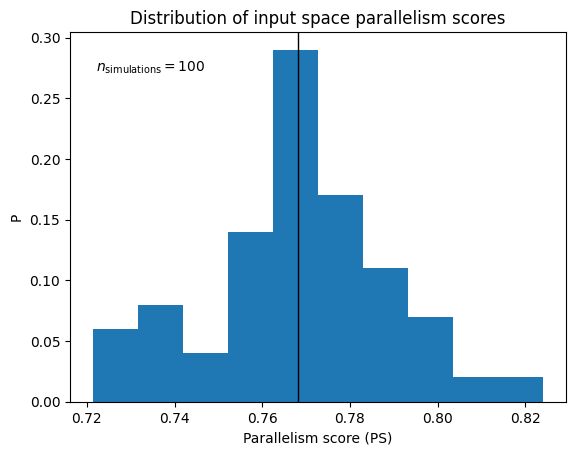

In [5]:
hist_fig = plt.figure()
par_df = geo_df[['parallelism', 'sim_id']].groupby('sim_id').mean().reset_index()
plt.hist(par_df.parallelism, weights=1/par_df.shape[0]*np.ones(par_df.shape[0]))
plt.xlabel('Parallelism score (PS)')
plt.ylabel('P')
plt.axvline(np.mean(par_df.parallelism), linewidth=1, color='black')
plt.title('Distribution of input space parallelism scores')
n_str = r'$n_{\text{simulations}} = $' + str(par_df.shape[0])
plt.annotate(n_str, [0.15, 0.8], xycoords='figure fraction')

##### Save output:

In [111]:
if save_output:

    # Save results dataframe:
    if not os.path.exists(base_output_directory):
        pathlib.Path(base_output_directory).mkdir(parents=True, exist_ok=True)
    curr_output_directory=increment_dir_name(base_output_directory, run_base_name)
    if not os.path.exists(curr_output_directory):
        pathlib.Path(curr_output_directory).mkdir(parents=True, exist_ok=True)

    # Save whisker simulation:
    #sim_path = os.path.join(curr_output_directory, 'simulated_contacts.pickle')
    #pickle.dump(, open(sim_path, 'wb'))
    
    # Save figures:
    plt.figure(hist_fig)
    file_basename = 'hist_ps'
    ps_png_path = os.path.join(curr_output_directory, file_basename+'.png')
    plt.savefig(ps_png_path)
    ps_svg_path =  os.path.join(curr_output_directory, file_basename+'.svg')
    plt.savefig(ps_svg_path)

    M = Metadata()
    metadata_consts = find_df_constants(hparams_df)

    # Do some converstions to make hyperparameters JSON serializable:
    for key in metadata_consts:
        if type(metadata_consts[key]) == np.bool:
            metadata_consts[key] = int(metadata_consts[key])
        M.add_param(key, metadata_consts[key])
    #M.add_output(sim_path)
    M.add_output(ps_png_path)
    M.add_output(ps_svg_path)
    metadata_path = os.path.join(curr_output_directory, 'simulate_contacts_metadata.json')
    write_metadata(M, metadata_path)

Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/input_geo/run008/hist_ps.png...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/input_geo/run008/hist_ps.svg...


In [8]:
geo_df[['sim_id', 'dichotomy', 'train_partition', 'parallelism']]\
.groupby(['sim_id', 'dichotomy', 'train_partition']).mean()\
.groupby(['sim_id', 'dichotomy']).mean()\
.groupby(['sim_id']).mean().reset_index()

,sim_id,parallelism
0,02Laf8he8d,0.770489
1,03A31w26br,0.784660
2,0ZHVF8oUoG,0.767742
3,0aEP3oGZeB,0.767277
4,0wqkYpr7Vt,0.752902
...,...,...
95,xeAwe5XmW0,0.758835
96,xkuiyXkNh6,0.763458
97,xsiA415ZQd,0.726145
98,yTVxVMGCVr,0.753957


In [10]:
geo_df[['dichotomy', 'train_partition']]

,dichotomy,train_partition
0,0,0
1,0,1
2,1,0
3,1,1
0,0,0
...,...,...
3,1,1
0,0,0
1,0,1
2,1,0
